In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import scipy.stats as stats
import glob
import os

In [2]:
# Read in the files which 
files = glob.glob('../data/correlation_data/*.csv')

In [3]:
# Concatentate all the files into a single dataframe
# Start with the first dataframe
base_df = pd.read_csv(files[0]).iloc[:, 1:]
suffix = os.path.splitext(files[0])[0].replace('/data/correlation_data/', '').replace('_blood_correlation', '')
base_df.columns = [f"{col}_{suffix}" for col in base_df.columns]

# Loop through the remaining files and merge them
for x, file in enumerate(files[1:]):
    x = x + 1
    # Read the current file
    temp_df = pd.read_csv(file).iloc[:, 1:]
    
    # Extract a suffix from the filename
    suffix = os.path.splitext(files[x])[0].replace('/data/correlation_data/', '').replace('_blood_correlation', '')
    
    # Add the suffix to each column name
    temp_df.columns = [f"{col}_{suffix}" for col in temp_df.columns]
    
    # Merge with the base dataframe
    # Assuming you have a common index or key column to merge on
    # If using index:
    base_df = pd.merge(base_df, temp_df, left_on = 'Feature_..GzmB_pos_CD56_CD8_T_cell', right_on = 'Feature_' + suffix)
 



In [4]:
base_df.columns = base_df.columns.str.replace('..', '', regex=False)
base_df.columns

Index(['Feature_GzmB_pos_CD56_CD8_T_cell',
       'Correlation_GzmB_pos_CD56_CD8_T_cell',
       'P-value_GzmB_pos_CD56_CD8_T_cell', 'Feature_GMP', 'Correlation_GMP',
       'P-value_GMP', 'Feature_hb', 'Correlation_hb', 'P-value_hb',
       'Feature_blast', 'Correlation_blast', 'P-value_blast', 'Feature_neut',
       'Correlation_neut', 'P-value_neut', 'Feature_GzmB_pos_CD8',
       'Correlation_GzmB_pos_CD8', 'P-value_GzmB_pos_CD8', 'Feature_plt',
       'Correlation_plt', 'P-value_plt'],
      dtype='object')

In [5]:
base_df

,Feature_GzmB_pos_CD56_CD8_T_cell,Correlation_GzmB_pos_CD56_CD8_T_cell,P-value_GzmB_pos_CD56_CD8_T_cell,Feature_GMP,Correlation_GMP,P-value_GMP,Feature_hb,Correlation_hb,P-value_hb,Feature_blast,...,P-value_blast,Feature_neut,Correlation_neut,P-value_neut,Feature_GzmB_pos_CD8,Correlation_GzmB_pos_CD8,P-value_GzmB_pos_CD8,Feature_plt,Correlation_plt,P-value_plt
0,CXCL5,0.700000,0.003666,CXCL5,0.017857,0.949635,CXCL5,0.348786,0.185499,CXCL5,...,0.348923,CXCL5,-0.192789,0.474389,CXCL5,0.592857,0.019846,CXCL5,0.558824,0.024437
1,IL12p70,0.671429,0.006128,IL12p70,0.200000,0.474814,IL12p70,-0.145695,0.590305,IL12p70,...,0.600919,IL12p70,0.020603,0.939629,IL12p70,0.317857,0.248291,IL12p70,0.117647,0.664341
2,FLT3LG,0.610714,0.015593,FLT3LG,-0.396429,0.143495,FLT3LG,0.460633,0.072559,FLT3LG,...,0.303839,FLT3LG,0.014717,0.956860,FLT3LG,0.560714,0.029676,FLT3LG,0.558824,0.024437
3,IL12B,0.592857,0.019846,IL12B,0.264286,0.341174,IL12B,-0.207506,0.440621,IL12B,...,0.009144,IL12B,0.013245,0.961171,IL12B,0.628571,0.012080,IL12B,0.152941,0.571745
4,CCL8,0.553571,0.032287,CCL8,-0.260714,0.347979,CCL8,0.426785,0.099223,CCL8,...,0.667384,CCL8,-0.294334,0.268478,CCL8,0.214286,0.443141,CCL8,0.355882,0.176104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,IL18R1,-0.489286,0.064160,IL18R1,-0.175000,0.532748,IL18R1,0.044150,0.871028,IL18R1,...,0.050930,IL18R1,-0.002943,0.991368,IL18R1,-0.307143,0.265473,IL18R1,-0.358824,0.172304
243,TNFSF11,-0.492857,0.061951,TNFSF11,-0.289286,0.295665,TNFSF11,0.272259,0.307665,TNFSF11,...,0.020933,TNFSF11,0.010302,0.969795,TNFSF11,-0.350000,0.200945,TNFSF11,-0.355882,0.176104
244,SCG2,-0.525000,0.044484,SCG2,-0.267857,0.334444,SCG2,0.051508,0.849744,SCG2,...,0.423159,SCG2,0.512141,0.042545,SCG2,-0.328571,0.231810,SCG2,-0.450000,0.080296
245,CSF3,-0.539286,0.038022,CSF3,-0.067857,0.810109,CSF3,0.108904,0.688070,CSF3,...,0.145937,CSF3,-0.309051,0.244134,CSF3,-0.635714,0.010861,CSF3,-0.108824,0.688288


In [6]:
# Add a useful index to the dataframe
base_df.index = base_df['Feature_GzmB_pos_CD56_CD8_T_cell']
base_df = base_df.loc[:, ~base_df.columns.str.contains('Feature')]

In [7]:
# Create a function to filter dataframes based on whether a single observation is greater than a specific value
def filter_dataframe(df, corr_columns, lower_threshold=-0.8, upper_threshold=0.8):
    """
    Filter dataframe rows based on correlation values in specified columns.
    
    Parameters:
    df (DataFrame): Input dataframe with correlation columns
    corr_columns (list): List of column names containing correlation values
    lower_threshold, upper_threshold: Thresholds for filtering
    
    Returns:
    DataFrame: Filtered dataframe with only rows meeting the criteria
    """
    # Create a mask to mark rows that should be kept
    mask = pd.Series(False, index=df.index)
    
    # For each correlation column
    for corr_col in corr_columns:
        if corr_col in df.columns:
            # Update mask to keep rows where the correlation is outside our threshold range
            mask = mask | (df[corr_col] <= lower_threshold) | (df[corr_col] >= upper_threshold)
    
    # Return filtered dataframe
    return df[mask]

In [8]:
# List the correlation columns we want to plot
corr_columns = [x for x in base_df.columns  if 'Correlation' in x ]
#base_df.index = base_df['Feature_hb']
# Apply the filter
base_df1 = filter_dataframe(base_df, corr_columns, lower_threshold=-0.6, upper_threshold=0.6)

<Figure size 288x360 with 0 Axes>

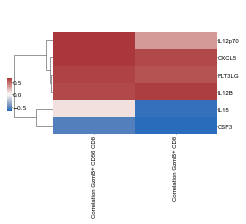

In [9]:
# Make a heatmap which describes the correlations in CD8 T cells
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


corr_columns = ['Correlation_GzmB_pos_CD56_CD8_T_cell', 'Correlation_GzmB_pos_CD8']
base_df3 = filter_dataframe(base_df, corr_columns, lower_threshold=-0.6, upper_threshold=0.6)

plt.figure(figsize=(4, 5))
cbar_pos = (0.02, 0.8, 0.03, 0.18)

cg = sns.clustermap(data = base_df3.loc[:, base_df3.columns.isin(corr_columns)], 
                cmap = 'vlag', figsize = (4, 5), col_cluster = False, cbar_pos = cbar_pos, 
                   vmin = -0.65, vmax = 0.65)

cg.ax_heatmap.set_ylabel('')
yticks = cg.ax_heatmap.get_yticklabels()
yticks = [text.get_text() for text in yticks]
yticks = [x.replace('IFNL2; IFNL3', 'IFNL2/3') for x in yticks]

# Set new font properties for ytick labels
cg.ax_heatmap.set_yticklabels(
    yticks, 
    fontfamily='Arial',  # Change font family
    fontsize=6,         # Change font size

)

# Get all x-tick labels
xlabels = cg.ax_heatmap.get_xticklabels()
# Extract the text strings from the Text objects
xlabels = [text.get_text() for text in xlabels]

# Modify the text strings

xlabels = [x.replace('_pos_', '+_') for x in xlabels]
xlabels = [x.replace('_T_cell', '') for x in xlabels]

xlabels = [x.replace('_', ' ') for x in xlabels]

cg.ax_heatmap.set_xticklabels(xlabels)
cg.ax_heatmap.set_xticklabels(
    xlabels, 
    fontfamily='Arial',  # Change font family
    fontsize=6)

cg.ax_heatmap.tick_params(
    axis='both',
    length=0.5,     # Length of the tick marks
    width=0.5, 
    pad=0.2
)

# # Get current position
pos = cg.cax.get_position()

# Make it 50% thinner but keep same height and position
cg.cax.set_position([pos.x0, pos.y0 *  0.85, pos.width * 0.5, pos.height * 0.5])

cg.cax.tick_params(labelsize=6, length = 0.5, pad = 0.5)
#cg.savefig('blood_t_cell_correlation_clustermap.pdf')

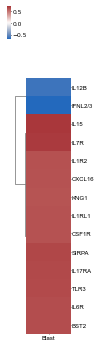

In [10]:
# Make a heatmap which describes the correlations in blasts

corr_columns = ['Correlation_blast']

base_df4 = filter_dataframe(base_df, corr_columns, lower_threshold=-0.6, upper_threshold=0.6)
base_df4_sorted = base_df4.sort_values('Correlation_blast', ascending=False)

cg = sns.clustermap(data = base_df4_sorted.loc[:, base_df4_sorted.columns.isin(corr_columns)], 
                cmap = 'vlag', figsize = (2.25, 5), col_cluster=False,  # Since I only have a single column
                    row_cluster=True,   # Enable row clustering (this is default)
                    method='average',   # Clustering linkage method (optional)
                    metric='euclidean')

cg.ax_heatmap.set_ylabel('')
yticks = cg.ax_heatmap.get_yticklabels()
yticks = [text.get_text() for text in yticks]
yticks = [x.replace('IFNL2; IFNL3', 'IFNL2/3') for x in yticks]
# Set new font properties for ytick labels
cg.ax_heatmap.set_yticklabels(
    yticks, 
    fontfamily='Arial',  # Change font family
    fontsize=6,         # Change font size

)

# Get all x-tick labels
xlabels = cg.ax_heatmap.get_xticklabels()
# Extract the text strings from the Text objects
xlabels = [text.get_text() for text in xlabels]

# Modify the text strings
xlabels = [x.replace('Correlation_', '') for x in xlabels]
xlabels = [x.replace('_pos_', '+_') for x in xlabels]
xlabels = [x.replace('_T_cell', '') for x in xlabels]
xlabels = [x.replace('neut', 'Neutrophils') for x in xlabels] 
xlabels = [x.replace('blast', 'Blast') for x in xlabels]
xlabels = [x.replace('hb', 'Haemoglobin') for x in xlabels]
xlabels = [x.replace('plt', 'Platelet') for x in xlabels]
xlabels = [x.replace('_', ' ') for x in xlabels]

cg.ax_heatmap.set_xticklabels(xlabels)
cg.ax_heatmap.set_xticklabels(
    xlabels, 
    fontfamily='Arial',  # Change font family
    fontsize=6)

cg.ax_heatmap.tick_params(
    axis='both',
    length=0.5,     # Length of the tick marks
    width=0.5, 
    pad=0.2
)

# Get current position
pos = cg.cax.get_position()

# Make it 50% thinner but keep same height and position
cg.cax.set_position([pos.x0, pos.y0 * 1.125, pos.width * 0.5, pos.height * 0.5])

cg.cax.tick_params(labelsize=6, length = 0.5, pad = 0.5)
#cg.savefig('blood_gmp_blast_correlation_clustermap.pdf')